In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
# Read Data

df = pd.read_csv("../data/clean_resume_data.csv")

In [3]:
# Some Info About Data

print("Show First 5 Samples of data:")
print(df.head())

print(f"Shape of data is: {df.shape}")

print("Different Categories in data:")
print(df["Category"].value_counts())

Show First 5 Samples of data:
         ID Category                                            Feature
0  16852973       HR  hr administrator marketing associate hr admini...
1  22323967       HR  hr specialist hr operations summary media prof...
2  33176873       HR  hr director summary years experience recruitin...
3  27018550       HR  hr specialist summary dedicated driven dynamic...
4  17812897       HR  hr manager skill highlights hr skills hr depar...
Shape of data is: (2484, 3)
Different Categories in data:
Category
INFORMATION-TECHNOLOGY    120
BUSINESS-DEVELOPMENT      120
ADVOCATE                  118
CHEF                      118
ENGINEERING               118
ACCOUNTANT                118
FINANCE                   118
FITNESS                   117
AVIATION                  117
SALES                     116
BANKING                   115
HEALTHCARE                115
CONSULTANT                115
CONSTRUCTION              112
PUBLIC-RELATIONS          111
HR                   

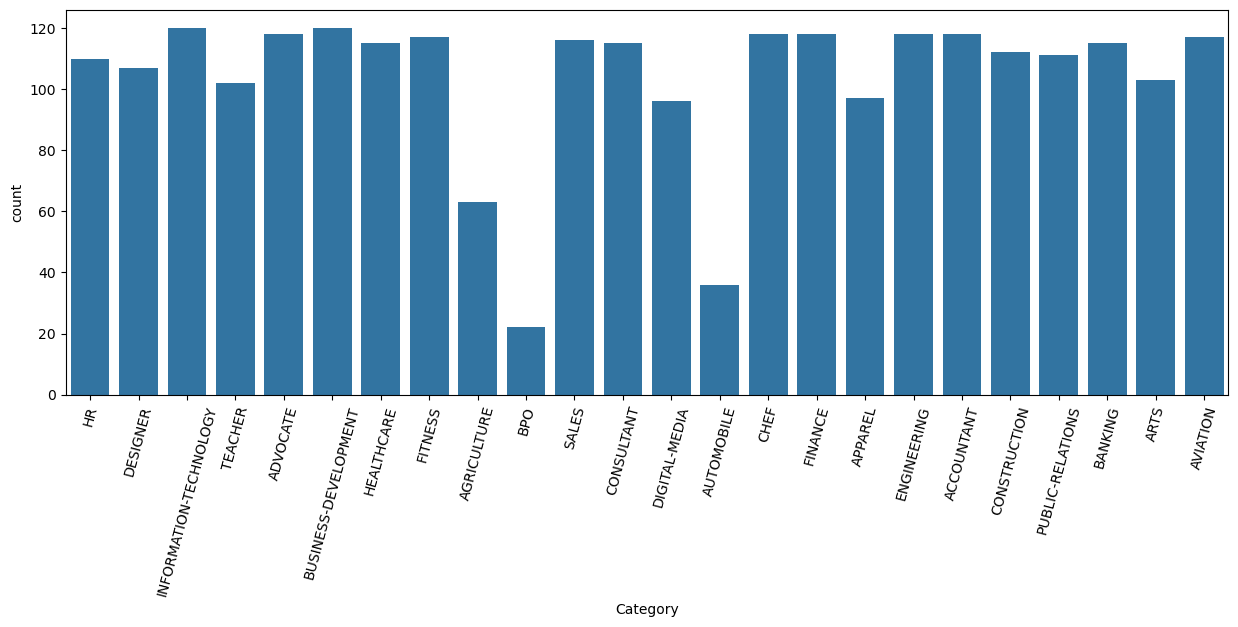

In [4]:
# Show different Categories

plt.figure(figsize=(15, 5))
sns.countplot(x = "Category", data = df)
plt.xticks(rotation = 75)
plt.show()

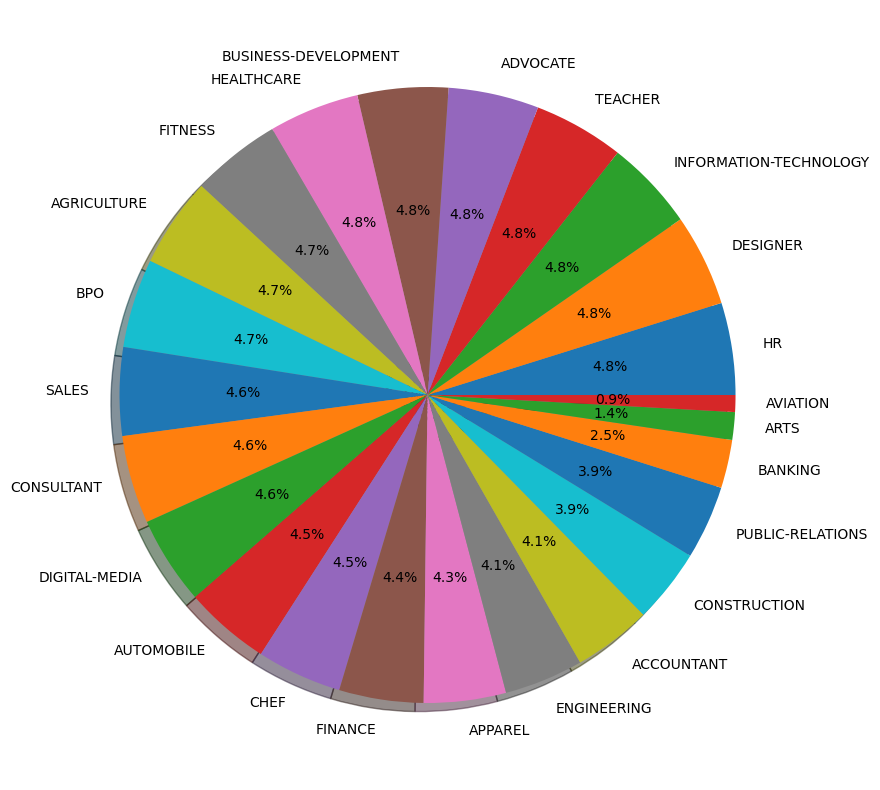

In [5]:
# Show different Categories

counts = df["Category"].value_counts()
labels = df["Category"].unique()

plt.figure(figsize=(15,10))
plt.pie(counts, labels=labels, autopct="%1.1f%%", shadow=True)
plt.show()

In [6]:
# Check Null values

print("Null values:")
print(df.isnull().sum())

df.dropna(inplace = True)

Null values:
ID          0
Category    0
Feature     1
dtype: int64


In [7]:
# Balance Data

from sklearn.utils import resample

max_count = df["Category"].value_counts().max()

balanced_data = []
for category in df["Category"].unique():
  category_data = df[df["Category"] == category]

  if len(category_data) < max_count:
    balanced_category_data = resample(category_data, replace = True, n_samples = max_count, random_state = 42)
  else:
    balanced_category_data = resample(category_data, replace = False, n_samples = max_count, random_state = 42)

  balanced_data.append(balanced_category_data)

balanced_df = pd.concat(balanced_data)

print("Number Of Samples Per Category:")
print(balanced_df["Category"].value_counts())

Number Of Samples Per Category:
Category
HR                        120
DESIGNER                  120
INFORMATION-TECHNOLOGY    120
TEACHER                   120
ADVOCATE                  120
BUSINESS-DEVELOPMENT      120
HEALTHCARE                120
FITNESS                   120
AGRICULTURE               120
BPO                       120
SALES                     120
CONSULTANT                120
DIGITAL-MEDIA             120
AUTOMOBILE                120
CHEF                      120
FINANCE                   120
APPAREL                   120
ENGINEERING               120
ACCOUNTANT                120
CONSTRUCTION              120
PUBLIC-RELATIONS          120
BANKING                   120
ARTS                      120
AVIATION                  120
Name: count, dtype: int64


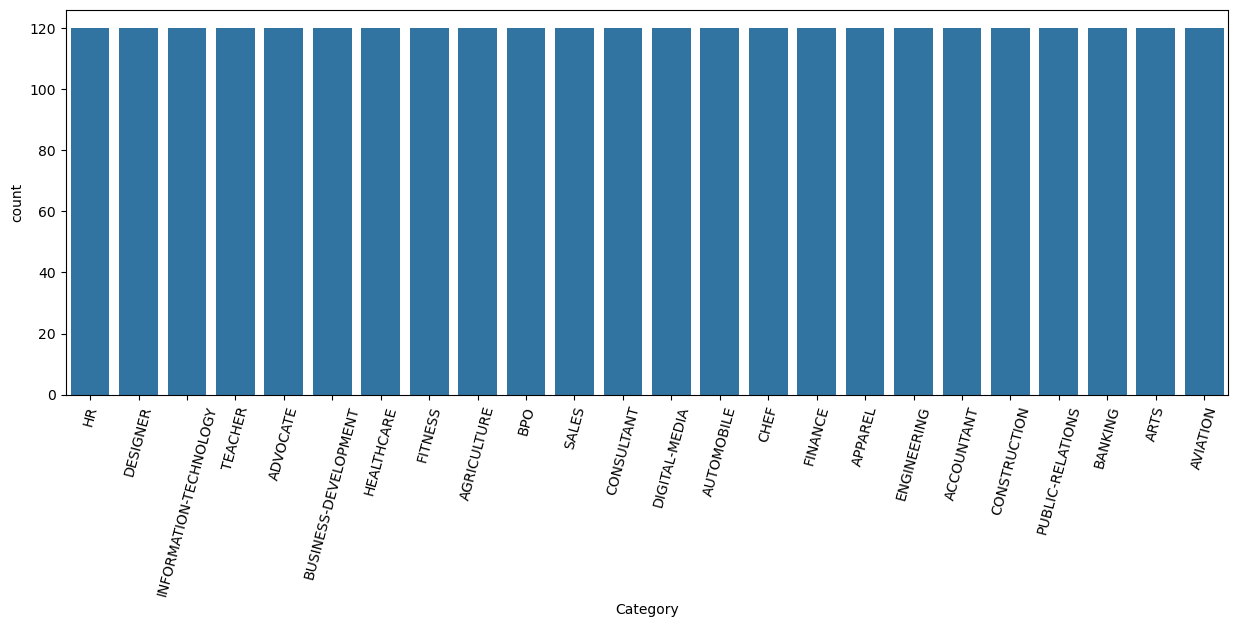

In [8]:
# Show different Categories for balanced data

plt.figure(figsize=(15, 5))
sns.countplot(x = "Category", data = balanced_df)
plt.xticks(rotation = 75)
plt.show()

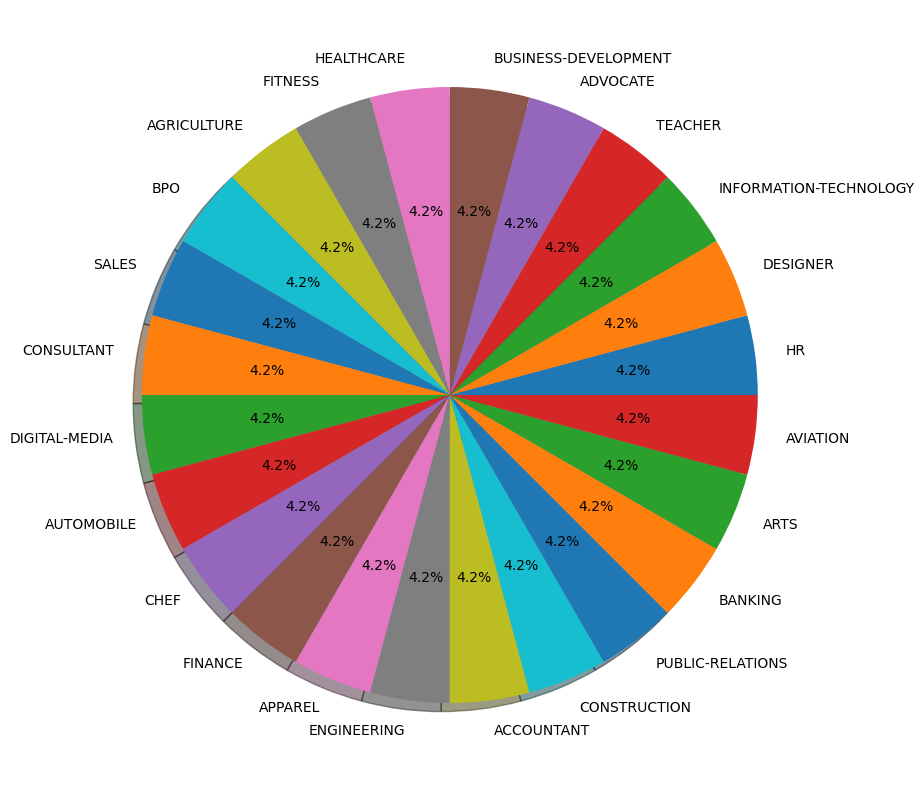

In [9]:
# Show different Categories for balanced data

counts = balanced_df["Category"].value_counts()
labels = balanced_df["Category"].unique()

plt.figure(figsize=(15,10))
plt.pie(counts, labels=labels, autopct="%1.1f%%", shadow=True)
plt.show()

In [10]:
# Check Null values for balanced data

print("Null values:")
print(balanced_df.isnull().sum())

Null values:
ID          0
Category    0
Feature     0
dtype: int64


In [11]:
# Clean Text

import re

def cleanResume(txt):
  # To remove Links
  cleanText = re.sub("http\S+\s", " ", txt)
  # To remove RT, cc
  cleanText = re.sub("RT|cc", " ", cleanText)
  # To remove Hashtags
  cleanText = re.sub("#\S+\s", " ", cleanText)
  # To remove Mentions
  cleanText = re.sub("#@\S+", " ", cleanText)
  # To remove Punctutations
  cleanText = re.sub("[%s]" % re.escape(""""!"#$%&'()*+,-./:;<=>?@[\]^_`{|}~"""), " ", cleanText)
  # To remove Non-ASCII
  cleanText = re.sub(r'[^\x00-\x7f]', " ", cleanText)
  # To remove Spaces
  cleanText = re.sub(r'\s+', " ", cleanText)

  return cleanText

<>:7: SyntaxWarning: invalid escape sequence '\S'
<>:11: SyntaxWarning: invalid escape sequence '\S'
<>:13: SyntaxWarning: invalid escape sequence '\S'
<>:15: SyntaxWarning: invalid escape sequence '\]'
<>:7: SyntaxWarning: invalid escape sequence '\S'
<>:11: SyntaxWarning: invalid escape sequence '\S'
<>:13: SyntaxWarning: invalid escape sequence '\S'
<>:15: SyntaxWarning: invalid escape sequence '\]'
C:\Users\Moham\AppData\Local\Temp\ipykernel_15528\1606045969.py:7: SyntaxWarning: invalid escape sequence '\S'
  cleanText = re.sub("http\S+\s", " ", txt)
C:\Users\Moham\AppData\Local\Temp\ipykernel_15528\1606045969.py:11: SyntaxWarning: invalid escape sequence '\S'
  cleanText = re.sub("#\S+\s", " ", cleanText)
C:\Users\Moham\AppData\Local\Temp\ipykernel_15528\1606045969.py:13: SyntaxWarning: invalid escape sequence '\S'
  cleanText = re.sub("#@\S+", " ", cleanText)
C:\Users\Moham\AppData\Local\Temp\ipykernel_15528\1606045969.py:15: SyntaxWarning: invalid escape sequence '\]'
  cleanTex

In [12]:
# Clean Resume

balanced_df["Feature"] = balanced_df["Feature"].apply(lambda x: cleanResume(x))

In [13]:
# Split Data

from sklearn.model_selection import train_test_split

X = balanced_df["Feature"]
y = balanced_df["Category"]

x_train, x_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"X Train Shape {x_train.shape}")
print(f"X Test Shape {x_test.shape}")

X Train Shape (2304,)
X Test Shape (576,)


In [14]:
# Apply Tfidf

from sklearn.feature_extraction.text import TfidfVectorizer

tfidf = TfidfVectorizer()
tfidf.fit(x_train)

x_train_tf = tfidf.transform(x_train)
x_test_tf = tfidf.transform(x_test)

In [15]:
# Train Model

from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(n_estimators=200)
rf.fit(x_train_tf, y_train)

,n_estimators,200
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [16]:
# Evaluate Model

from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

y_pred = rf.predict(x_test_tf)
acc = accuracy_score(y_test, y_pred)
classification_re = classification_report(y_test, y_pred)

print(f"Model Accuracy is: {acc}")
print(f"Classification Report:\n{classification_re}")

Model Accuracy is: 0.8645833333333334
Classification Report:
                        precision    recall  f1-score   support

            ACCOUNTANT       0.79      0.95      0.86        20
              ADVOCATE       0.77      0.69      0.73        29
           AGRICULTURE       0.95      0.91      0.93        23
               APPAREL       0.90      0.82      0.86        22
                  ARTS       1.00      0.67      0.80        24
            AUTOMOBILE       1.00      0.68      0.81        19
              AVIATION       0.97      1.00      0.98        28
               BANKING       0.93      0.64      0.76        22
                   BPO       1.00      1.00      1.00        15
  BUSINESS-DEVELOPMENT       0.56      0.83      0.67        18
                  CHEF       0.87      0.96      0.92        28
          CONSTRUCTION       0.96      1.00      0.98        25
            CONSULTANT       1.00      0.77      0.87        31
              DESIGNER       0.81      0.9

Text(0.5, 1.0, 'Confusion Matrix')

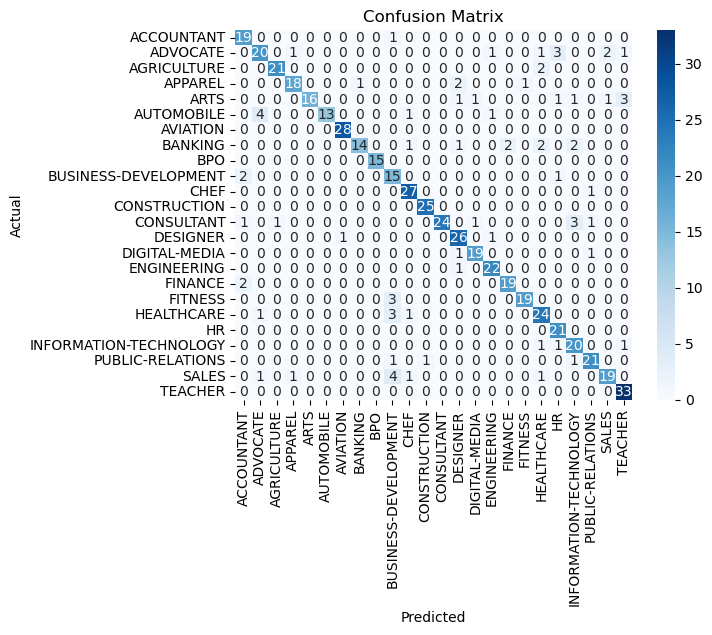

In [17]:
# Confusion Matrix

cf = confusion_matrix(y_test, y_pred)

sns.heatmap(cf, annot = True, cmap = "Blues", xticklabels = rf.classes_, yticklabels = rf.classes_)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")

In [18]:
# Save Model

import pickle

pickle.dump(tfidf, open("../saved_models/tfidf_category.pkl", "wb"))
pickle.dump(rf, open("../saved_models/rf_category.pkl", "wb"))